# Task 8: Logistic Regression

## Introduction to Logistic Regression

### What is Logistic Regression?

Logistic Regression is a **supervised learning** algorithm used for **classification** tasks (binary classification). Despite its name, it's a classification algorithm, not regression.

It predicts the probability of a binary outcome (0 or 1) using the logistic (sigmoid) function.

### When to Use Logistic Regression?

- Binary classification (yes/no, spam/not spam, fraud/not fraud)
- When you need probability scores
- When features have a linear relationship with log-odds
- As a baseline model for classification problems

## The Math Behind Logistic Regression

### 1. Sigmoid Function (Logistic Function)

The sigmoid function maps any real-valued number to the range (0, 1):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where $z = \mathbf{w} \cdot \mathbf{x} + b$

### 2. Decision Boundary

- If $\sigma(z) \geq 0.5$ (or $z \geq 0$), predict class 1
- If $\sigma(z) < 0.5$ (or $z < 0$), predict class 0

### 3. Cost Function (Log Loss)

We use Cross-Entropy Loss (Log Loss):

$$J(\mathbf{w}) = -\frac{1}{n}\sum_{i=1}^{n}[y^{(i)}\log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)})]$$

Where:
- $\hat{y}^{(i)}$ is the predicted probability
- $y^{(i)}$ is the actual label

### 4. Gradient Descent

The gradient of the cost function:

$$ \frac{\partial J}{\partial w_j} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}^{(i)} - y^{(i)})x_j^{(i)} $$

Update rule:

$$ w_j := w_j - \alpha \cdot \frac{\partial J}{\partial w_j} $$

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 2. Visualize Sigmoid Function

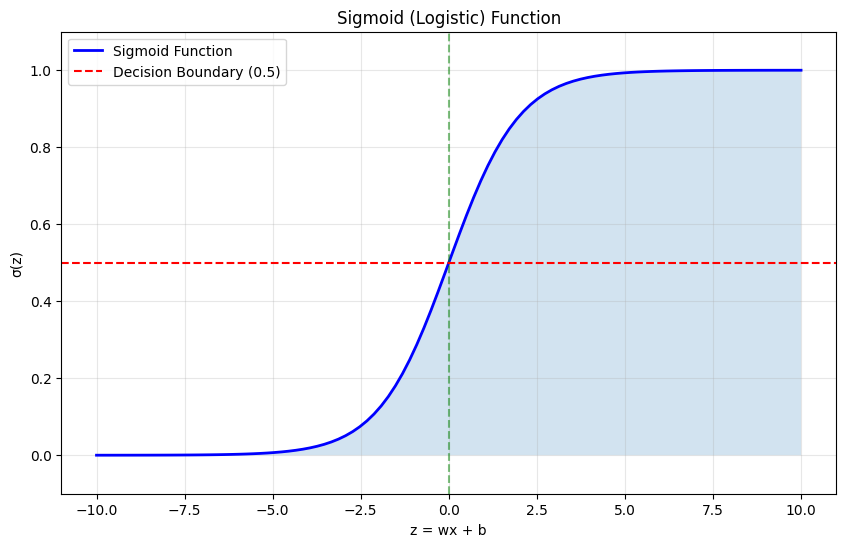

Key properties of Sigmoid:
  - σ(0) = 0.5
  - σ(2) = 0.8807970779778823
  - σ(-2) = 0.11920292202211755


In [2]:
def sigmoid(z):
    """Sigmoid (logistic) function"""
    return 1 / (1 + np.exp(-z))

# Plot sigmoid function
z = np.linspace(-10, 10, 100)
sigma = sigmoid(z)

plt.figure(figsize=(10, 6))
plt.plot(z, sigma, 'b-', linewidth=2, label='Sigmoid Function')
plt.axhline(y=0.5, color='r', linestyle='--', linewidth=1.5, label='Decision Boundary (0.5)')
plt.axvline(x=0, color='g', linestyle='--', linewidth=1.5, alpha=0.5)
plt.xlabel('z = wx + b')
plt.ylabel('σ(z)')
plt.title('Sigmoid (Logistic) Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.fill_between(z, sigma, alpha=0.2)
plt.show()

print("Key properties of Sigmoid:")
print(f"  - σ(0) = {sigmoid(0)}")
print(f"  - σ(2) = {sigmoid(2)}")
print(f"  - σ(-2) = {sigmoid(-2)}")

## 3. Generate Sample Data

Dataset Information:
  - Number of samples: 200
  - Number of features: 2
  - Classes: [0 1]
  - Class distribution: [100 100]


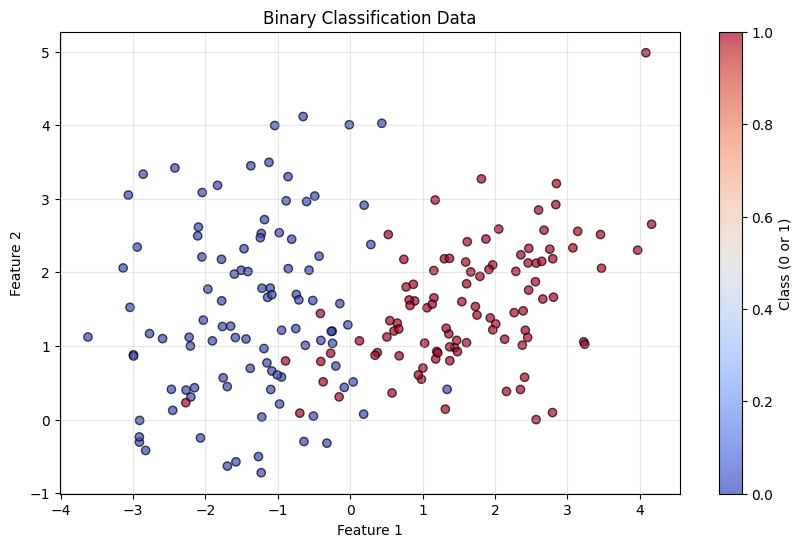

In [3]:
# Generate synthetic binary classification data
np.random.seed(42)

# Create a binary classification dataset
X, y = make_classification(
    n_samples=200, 
    n_features=2, 
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

print("Dataset Information:")
print(f"  - Number of samples: {X.shape[0]}")
print(f"  - Number of features: {X.shape[1]}")
print(f"  - Classes: {np.unique(y)}")
print(f"  - Class distribution: {np.bincount(y)}")

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='black', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary Classification Data')
plt.colorbar(label='Class (0 or 1)')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Implement Logistic Regression from Scratch

In [4]:
class LogisticRegressionFromScratch:
    """
    Logistic Regression implementation from scratch using Gradient Descent
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
    
    def _sigmoid(self, z):
        """Apply sigmoid function with numerical stability"""
        # Clip z to avoid overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def _compute_cost(self, X, y):
        """
        Compute Cross-Entropy (Log Loss) Cost Function
        
        J = -1/n * [y*log(y_hat) + (1-y)*log(1-y_hat)]
        """
        n = len(y)
        y_pred = self.predict_proba(X)
        
        # Clip to avoid log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        
        cost = -1/n * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        return cost
    
    def fit(self, X, y):
        """
        Fit the model using Gradient Descent
        
        Parameters:
        X: numpy array of shape (n_samples, n_features)
        y: numpy array of shape (n_samples,)
        """
        n_samples, n_features = X.shape
        
        # Initialize weights and bias to zero
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Gradient Descent optimization
        for i in range(self.n_iterations):
            # Linear model: z = w*x + b
            linear_output = np.dot(X, self.weights) + self.bias
            
            # Apply sigmoid function
            y_pred = self._sigmoid(linear_output)
            
            # Compute gradients
            # dw = (1/n) * X^T * (y_pred - y)
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            # db = (1/n) * sum(y_pred - y)
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Record cost for visualization
            if i % 100 == 0:
                cost = self._compute_cost(X, y)
                self.cost_history.append(cost)
        
        return self
    
    def predict_proba(self, X):
        """
        Return probability predictions
        """
        linear_output = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_output)
    
    def predict(self, X, threshold=0.5):
        """
        Make binary predictions
        """
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)
    
    def get_params(self):
        """Return model parameters"""
        return {
            'bias': self.bias,
            'weights': self.weights
        }

## 5. Train and Evaluate Models

In [5]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 160
Testing samples: 40


### 5.1 Train Logistic Regression from Scratch

In [6]:
# Train our implementation
model_from_scratch = LogisticRegressionFromScratch(
    learning_rate=0.1, 
    n_iterations=1000
)
model_from_scratch.fit(X_train, y_train)

# Make predictions
y_pred_scratch = model_from_scratch.predict(X_test)
y_proba_scratch = model_from_scratch.predict_proba(X_test)

# Get parameters
params = model_from_scratch.get_params()
print("=== Logistic Regression (From Scratch) ===")
print(f"Bias: {params['bias']:.4f}")
print(f"Weights: {params['weights']}")

=== Logistic Regression (From Scratch) ===
Bias: 0.9773
Weights: [ 2.50227834 -0.71682279]


### 5.2 Train using Scikit-Learn

In [7]:
# Train using Scikit-Learn
model_sklearn = LogisticRegression(random_state=42)
model_sklearn.fit(X_train, y_train)

# Make predictions
y_pred_sklearn = model_sklearn.predict(X_test)
y_proba_sklearn = model_sklearn.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (Scikit-Learn) ===")
print(f"Intercept: {model_sklearn.intercept_[0]:.4f}")
print(f"Coefficients: {model_sklearn.coef_[0]}")

=== Logistic Regression (Scikit-Learn) ===
Intercept: 1.0166
Coefficients: [ 2.25018996 -0.70559984]


## 6. Evaluate Model Performance

In [8]:
def evaluate_classification(y_true, y_pred, model_name):
    """Calculate and print classification metrics"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    
    return {'accuracy': accuracy, 'precision': precision, 
            'recall': recall, 'f1': f1, 'cm': cm}

In [9]:
# Evaluate both models
results_scratch = evaluate_classification(y_test, y_pred_scratch, "From Scratch")
results_sklearn = evaluate_classification(y_test, y_pred_sklearn, "Scikit-Learn")


=== From Scratch ===
Accuracy:  0.9500
Precision: 0.8947
Recall:    1.0000
F1 Score:  0.9444

Confusion Matrix:
[[21  2]
 [ 0 17]]

=== Scikit-Learn ===
Accuracy:  0.9000
Precision: 0.8095
Recall:    1.0000
F1 Score:  0.8947

Confusion Matrix:
[[19  4]
 [ 0 17]]


### 6.1 Detailed Classification Report

In [10]:
print("=== Classification Report (Scikit-Learn) ===")
print(classification_report(y_test, y_pred_sklearn, target_names=['Class 0', 'Class 1']))

=== Classification Report (Scikit-Learn) ===
              precision    recall  f1-score   support

     Class 0       1.00      0.83      0.90        23
     Class 1       0.81      1.00      0.89        17

    accuracy                           0.90        40
   macro avg       0.90      0.91      0.90        40
weighted avg       0.92      0.90      0.90        40



## 7. Visualize Results

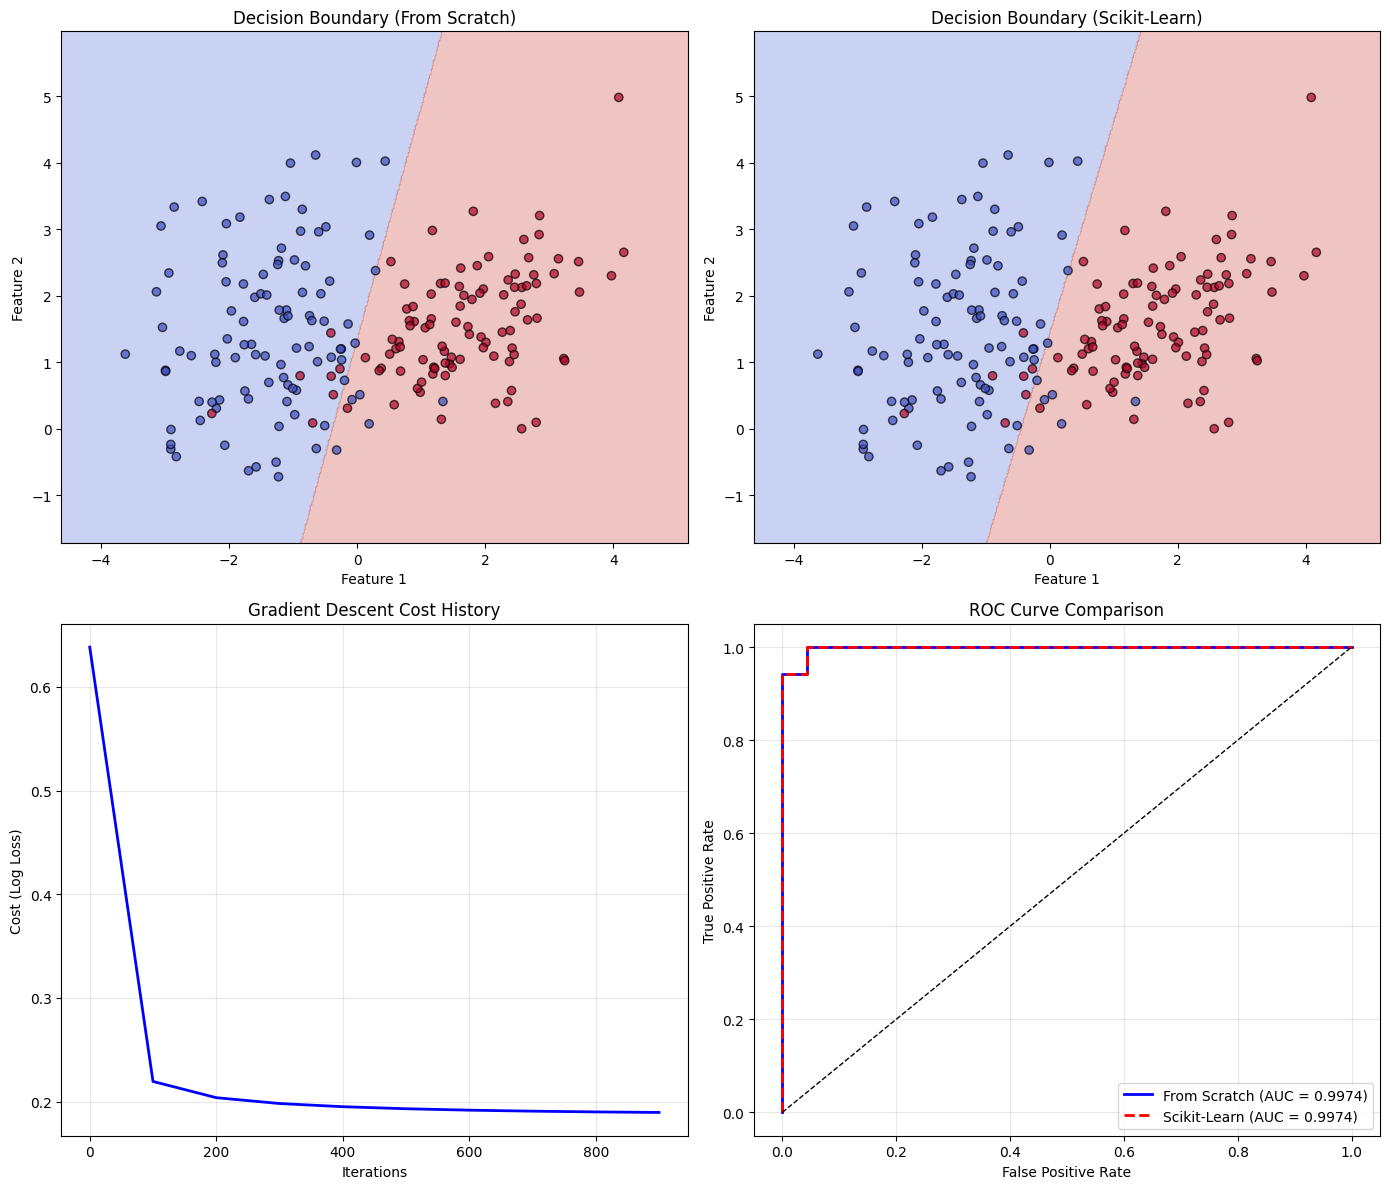

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Subplot 1: Decision Boundary (From Scratch)
ax1 = axes[0, 0]
h = 0.02  # step size
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model_from_scratch.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
ax1.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='black', alpha=0.7)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_title('Decision Boundary (From Scratch)')

# Subplot 2: Decision Boundary (Scikit-Learn)
ax2 = axes[0, 1]
Z2 = model_sklearn.predict(np.c_[xx.ravel(), yy.ravel()])
Z2 = Z2.reshape(xx.shape)
ax2.contourf(xx, yy, Z2, cmap='coolwarm', alpha=0.3)
ax2.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='black', alpha=0.7)
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_title('Decision Boundary (Scikit-Learn)')

# Subplot 3: Cost History (Gradient Descent)
ax3 = axes[1, 0]
ax3.plot(range(0, 1000, 100), model_from_scratch.cost_history, 'b-', linewidth=2)
ax3.set_xlabel('Iterations')
ax3.set_ylabel('Cost (Log Loss)')
ax3.set_title('Gradient Descent Cost History')
ax3.grid(True, alpha=0.3)

# Subplot 4: ROC Curve
ax4 = axes[1, 1]
fpr_scratch, tpr_scratch, _ = roc_curve(y_test, y_proba_scratch)
fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, y_proba_sklearn)
roc_auc_scratch = auc(fpr_scratch, tpr_scratch)
roc_auc_sklearn = auc(fpr_sklearn, tpr_sklearn)

ax4.plot(fpr_scratch, tpr_scratch, 'b-', linewidth=2, label=f'From Scratch (AUC = {roc_auc_scratch:.4f})')
ax4.plot(fpr_sklearn, tpr_sklearn, 'r--', linewidth=2, label=f'Scikit-Learn (AUC = {roc_auc_sklearn:.4f})')
ax4.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curve Comparison')
ax4.legend(loc='lower right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Real-World Example: Breast Cancer Detection

In [12]:
from sklearn.datasets import load_breast_cancer

# Load breast cancer dataset
data = load_breast_cancer()
X_cancer = data.data
y_cancer = data.target

print("Breast Cancer Dataset:")
print(f"  - Number of samples: {X_cancer.shape[0]}")
print(f"  - Number of features: {X_cancer.shape[1]}")
print(f"  - Classes: {data.target_names}")
print(f"  - Class distribution: {np.bincount(y_cancer)}")

# Split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

# Standardize features (important for logistic regression)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

# Train from scratch
model_cancer = LogisticRegressionFromScratch(learning_rate=0.1, n_iterations=5000)
model_cancer.fit(X_train_scaled, y_train_c)
y_pred_cancer = model_cancer.predict(X_test_scaled)

# Train sklearn
model_cancer_sklearn = LogisticRegression(max_iter=1000)
model_cancer_sklearn.fit(X_train_scaled, y_train_c)
y_pred_cancer_sklearn = model_cancer_sklearn.predict(X_test_scaled)

print("\n=== Breast Cancer Classification Results ===")
print(f"\nFrom Scratch:")
print(f"  Accuracy: {accuracy_score(y_test_c, y_pred_cancer):.4f}")
print(f"  F1 Score: {f1_score(y_test_c, y_pred_cancer):.4f}")

print(f"\nScikit-Learn:")
print(f"  Accuracy: {accuracy_score(y_test_c, y_pred_cancer_sklearn):.4f}")
print(f"  F1 Score: {f1_score(y_test_c, y_pred_cancer_sklearn):.4f}")

Breast Cancer Dataset:
  - Number of samples: 569
  - Number of features: 30
  - Classes: ['malignant' 'benign']
  - Class distribution: [212 357]

=== Breast Cancer Classification Results ===

From Scratch:
  Accuracy: 0.9825
  F1 Score: 0.9859

Scikit-Learn:
  Accuracy: 0.9737
  F1 Score: 0.9790


## 9. Key Takeaways

### What We Learned:

1. **Logistic Regression** is a classification algorithm, not regression

2. **Sigmoid Function** maps predictions to probabilities (0-1)

3. **Cost Function** (Log Loss) measures prediction error:
   - Penalizes confident wrong predictions heavily
   - Rewards confident correct predictions

4. **Gradient Descent** optimizes the weights to minimize cost

5. **Decision Boundary** separates classes based on threshold (0.5)

6. **Evaluation Metrics**:
   - Accuracy: Overall correctness
   - Precision: Of predicted positives, how many are true positives
   - Recall: Of actual positives, how many did we catch
   - F1: Harmonic mean of precision and recall
   - AUC-ROC: Trade-off between TPR and FPR

7. **Feature Scaling** is important for gradient descent convergence

## Summary

This notebook demonstrated:
- ✅ Introduction to Logistic Regression
- ✅ Math behind Logistic Regression (Sigmoid, Cost Function, Gradient Descent)
- ✅ Logistic Regression implementation from scratch
- ✅ Logistic Regression using Scikit-Learn
- ✅ Model evaluation with multiple metrics
- ✅ Decision boundary visualization
- ✅ ROC curve and AUC
- ✅ Real-world example (Breast Cancer Detection)